# Taller de Matematicas Especiales

*Unidad 1*

*Brayan Estiven Díaz Álvarez*

### 1. Sistema de ecuaciones

Para cada uno de los siguientes sistemas, determine si tiene solución, clasifíquelo según corresponda y
represente gráficamente el conjunto solución.

In [42]:
import matplotlib.pyplot as plt

def graficar_sistema(A, b, rango=(-5, 5), n=30, titulo=None, punto_solucion=None, colores=None):
    """
    Grafica un sistema de ecuaciones lineales.
    - Si A tiene 2 columnas: grafica rectas en el plano XY.
    - Si A tiene 3 columnas: grafica planos en el espacio XYZ.

    punto_solucion: tupla (x, y) o (x, y, z) para resaltar la solución, si existe.
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float).ravel()
    n_ecuaciones, n_vars = A.shape

    if n_vars not in (2, 3):
        raise ValueError("Solo se pueden graficar sistemas de 2 o 3 variables.")

    if colores is None:
        colores = ['r', 'g', 'b', 'm', 'c', 'y']

    valores = np.linspace(rango[0], rango[1], n)
    fig = plt.figure(figsize=(7, 6))

    if n_vars == 3:
        ax = fig.add_subplot(111, projection='3d')
        X, Z = np.meshgrid(valores, valores)
        for i, (coef, d) in enumerate(zip(A, b)):
            a, cy, cz = coef
            color = colores[i % len(colores)]
            # Se despeja la variable con el coeficiente más grande para evitar dividir por ~0
            if abs(cy) >= abs(a) and abs(cy) >= abs(cz):
                Y = (d - a * X - cz * Z) / cy
                ax.plot_surface(X, Y, Z, alpha=0.5, color=color)
            elif abs(a) >= abs(cz):
                Xp = (d - cy * X - cz * Z) / a
                ax.plot_surface(Xp, X, Z, alpha=0.5, color=color)
            else:
                Zp = (d - a * X - cy * Z) / cz
                ax.plot_surface(X, Z, Zp, alpha=0.5, color=color)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

        if punto_solucion is not None:
            px, py, pz = punto_solucion
            ax.scatter([px], [py], [pz], color='black', s=50)
            ax.text(px, py, pz, f"  ({px:.2f}, {py:.2f}, {pz:.2f})")

    else:
        ax = fig.add_subplot(111)
        for i, (coef, d) in enumerate(zip(A, b)):
            a, cy = coef
            color = colores[i % len(colores)]
            if abs(cy) > 1e-9:
                y = (d - a * valores) / cy
                ax.plot(valores, y, color=color, label=f"Ec {i + 1}")
            else:
                x_fijo = d / a
                ax.axvline(x_fijo, color=color, label=f"Ec {i + 1}")
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_xlim(rango); ax.set_ylim(rango)
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

        if punto_solucion is not None:
            px, py = punto_solucion
            ax.scatter([px], [py], color='black', s=50, zorder=5)

    if titulo:
        ax.set_title(titulo)

    plt.tight_layout()
    plt.show()
    return fig, ax


In [84]:
import numpy as np

def analizar_sistema(A, b, titulo=None, rango=(-5, 5), n=30):
    """
    Usando el teorema de Rouché-Frobenius, clasifica un sistema Ax = b
    (sin solución, solución única, o infinitas soluciones), imprime la
    solución y grafica el resultado (rectas o planos según el número de incógnitas).
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float).reshape(-1, 1)

    n_ecuaciones, n_incognitas = A.shape
    A_aumentada = np.hstack((A, b))

    rango_A = np.linalg.matrix_rank(A)
    rango_aug = np.linalg.matrix_rank(A_aumentada)

    print("-" * 50)
    print(f"ANÁLISIS DEL SISTEMA ({n_ecuaciones} ecuaciones, {n_incognitas} incógnitas):")
    print(f"-> Rango de A: {rango_A}")
    print(f"-> Rango de [A|b]: {rango_aug}")
    print("-" * 50)

    nombres = ["x", "y", "z"] if n_incognitas <= 3 else [f"x{i + 1}" for i in range(n_incognitas)]

    def mostrar_solucion(solucion):
        print("Solución del sistema:")
        for nombre, valor in zip(nombres, solucion.flatten()):
            print(f"{nombre} = {valor:.2f}")

    # REGLA 1: Si los rangos son distintos, NO TIENE SOLUCIÓN EXACTA
    if rango_A != rango_aug:
        print("❌ ALERTA: EL SISTEMA NO TIENE SOLUCIÓN EXACTA.")
        print("💡 Acción: Se calcula la mejor aproximación mediante MÍNIMOS CUADRADOS.")

        solucion, residuos, _, _ = np.linalg.lstsq(A, b, rcond=None)
        mostrar_solucion(solucion)
        graficar_sistema(A, b, rango=rango, n=n, titulo=titulo or "Sistema incompatible", punto_solucion=solucion.flatten())

        return {
            "estado": "Sin solución exacta",
            "metodo_usado": "Mínimos Cuadrados",
            "solucion": solucion.flatten(),
            "error_residual_total": np.sqrt(residuos)[0] if residuos.size > 0 else 0.0
        }

    # REGLA 2: Los rangos son iguales -> el sistema SÍ tiene solución exacta
    if rango_A == n_incognitas:
        print("✅ EL SISTEMA TIENE SOLUCIÓN EXACTA ÚNICA.")

        # Si es cuadrada usamos solve (exacto); si no, lstsq (más robusto)
        if n_ecuaciones == n_incognitas:
            solucion = np.linalg.solve(A, b)
        else:
            solucion, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

        mostrar_solucion(solucion)
        graficar_sistema(A, b, rango=rango, n=n, titulo=titulo or "Sistema compatible determinado", punto_solucion=solucion.flatten())

        return {
            "estado": "Solución exacta única",
            "metodo_usado": "Eliminación exacta",
            "solucion": solucion.flatten()
        }

    # Caso restante: rango_A < n_incognitas -> infinitas soluciones
    print("⚠️ EL SISTEMA TIENE INFINITAS SOLUCIONES EXACTAS.")

    solucion, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    mostrar_solucion(solucion)
    graficar_sistema(A, b, rango=rango, n=n, titulo=titulo or "Sistema compatible indeterminado", punto_solucion=solucion.flatten())

    return {
        "estado": "Infinitas soluciones exactas",
        "metodo_usado": "Solución particular de mínimos cuadrados",
        "solucion": solucion.flatten()
    }


$$
\begin{cases} 
x - 2y - 3z = -1 \\ 
2x + y + z = 6 \\ 
x + 3y - 2z = 5 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (3 ecuaciones, 3 incógnitas):
-> Rango de A: 3
-> Rango de [A|b]: 3
--------------------------------------------------
✅ EL SISTEMA TIENE SOLUCIÓN EXACTA ÚNICA.
Solución del sistema:
x = 2.27
y = 1.13
z = 0.33


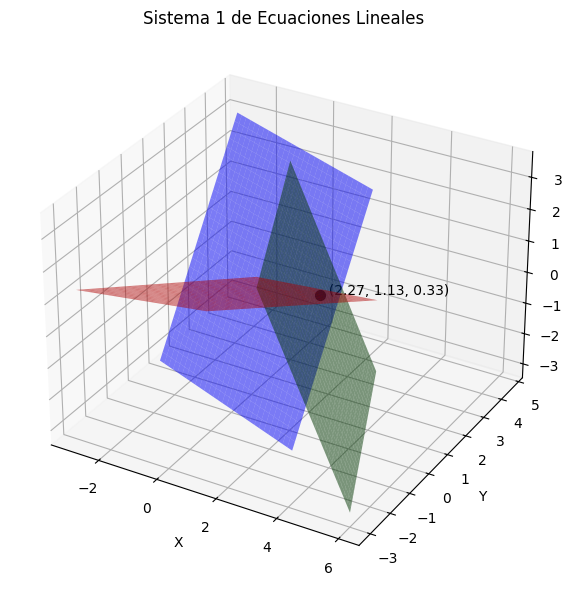

In [85]:

A = np.array([
    [1, -2,-3],
    [2, 1, 1],
    [1, 3, -2]
])

# Definir el vector de términos independientes B
B = np.array([-1, 6, 5])

# Ejemplo de uso
resultado = analizar_sistema(A, B, titulo="Sistema 1 de Ecuaciones Lineales", rango=(-3, 3), n=30)

$$
\begin{cases} 
2x + y + z = 0 \\ 
x - 2y - 2z = 0 \\ 
x + y + z = 0 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (3 ecuaciones, 3 incógnitas):
-> Rango de A: 2
-> Rango de [A|b]: 2
--------------------------------------------------
⚠️ EL SISTEMA TIENE INFINITAS SOLUCIONES EXACTAS.
Solución del sistema:
x = 0.00
y = 0.00
z = 0.00


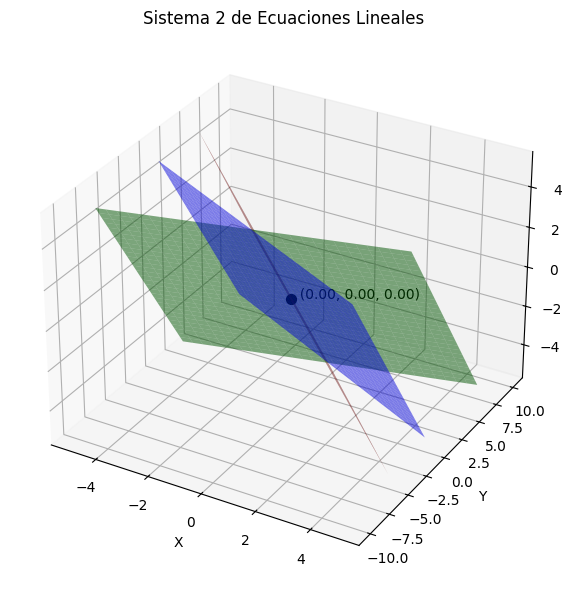

In [86]:
A = np.array([[2, 1, 1], [1, -2, -2], [1, 1, 1]])
B = np.array([0, 0, 0])

# Ejemplo de uso
resultado = analizar_sistema(A, B, titulo="Sistema 2 de Ecuaciones Lineales")

$$
\begin{cases} 
5x + 2z = 1 \\ 
y - 3z = 2 \\ 
2x + y = 3 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (3 ecuaciones, 3 incógnitas):
-> Rango de A: 3
-> Rango de [A|b]: 3
--------------------------------------------------
✅ EL SISTEMA TIENE SOLUCIÓN EXACTA ÚNICA.
Solución del sistema:
x = 0.09
y = 2.82
z = 0.27


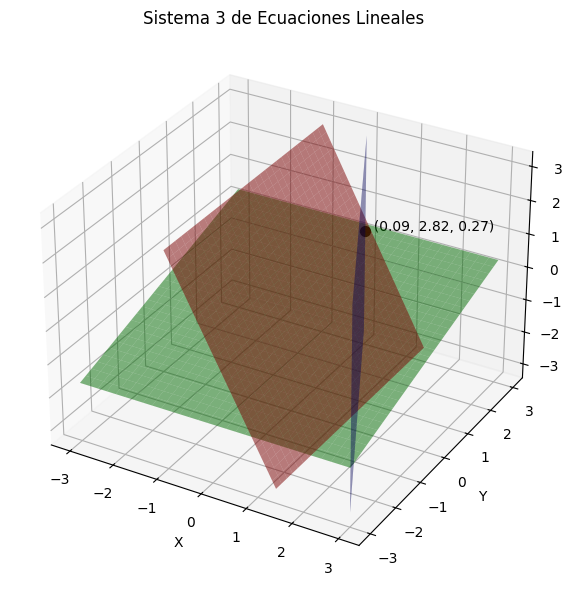

In [87]:
A = np.array([[5, 0, 2], [0, 1, -3], [2, 1, 0]])
B = np.array([1, 2, 3])

resultado = analizar_sistema(A, B, rango=(-3, 3), n=30, titulo="Sistema 3 de Ecuaciones Lineales")

$$
\begin{cases} 
2x + 6y - 4z = 1 \\ 
x + 3y - 2z = 4 \\ 
2x + y - 3z = -7 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (3 ecuaciones, 3 incógnitas):
-> Rango de A: 2
-> Rango de [A|b]: 3
--------------------------------------------------
❌ ALERTA: EL SISTEMA NO TIENE SOLUCIÓN EXACTA.
💡 Acción: Se calcula la mejor aproximación mediante MÍNIMOS CUADRADOS.
Solución del sistema:
x = -1.71
y = 2.27
z = 1.95


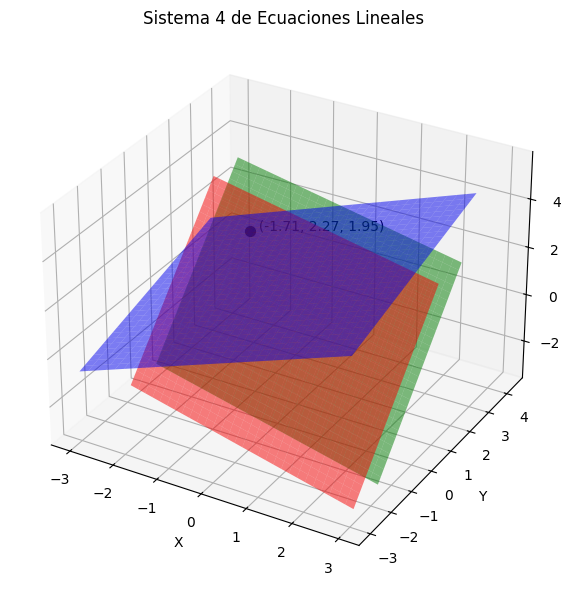

In [88]:
A = np.array([[2, 6, -4], [1, 3, -2], [2, 1, -3]])
B = np.array([1, 4, -7])

resultado = analizar_sistema(A, B, rango=(-3, 3), n=30, titulo="Sistema 4 de Ecuaciones Lineales")

$$
\begin{cases} 
3x - 2y + 5z = 7 \\ 
x + 4y - z = -2 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (2 ecuaciones, 3 incógnitas):
-> Rango de A: 2
-> Rango de [A|b]: 2
--------------------------------------------------
⚠️ EL SISTEMA TIENE INFINITAS SOLUCIONES EXACTAS.
Solución del sistema:
x = 0.53
y = -0.40
z = 0.92


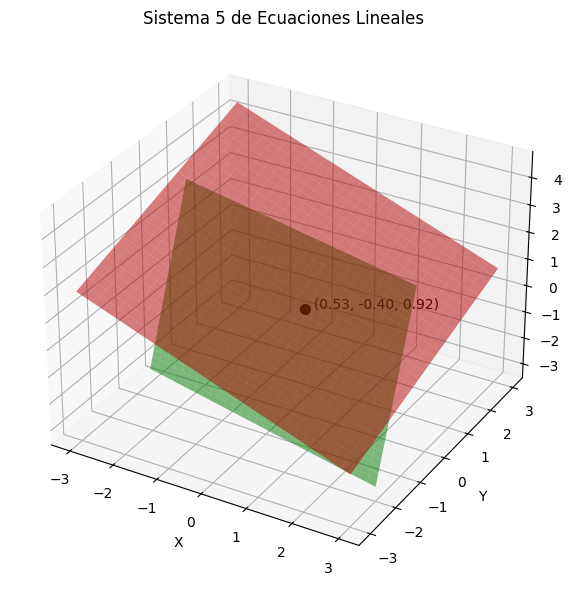

In [89]:
A = np.array([[3, -2, 5], [1, 4, -1]])
B = np.array([7, -2])

resultado = analizar_sistema(A, B, rango=(-3, 3), n=30, titulo="Sistema 5 de Ecuaciones Lineales")

$$
\begin{cases} 
4x - 3y = 1 \\ 
2x + y = -7 \\ 
-x + y = -1 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (3 ecuaciones, 2 incógnitas):
-> Rango de A: 2
-> Rango de [A|b]: 2
--------------------------------------------------
✅ EL SISTEMA TIENE SOLUCIÓN EXACTA ÚNICA.
Solución del sistema:
x = -2.00
y = -3.00


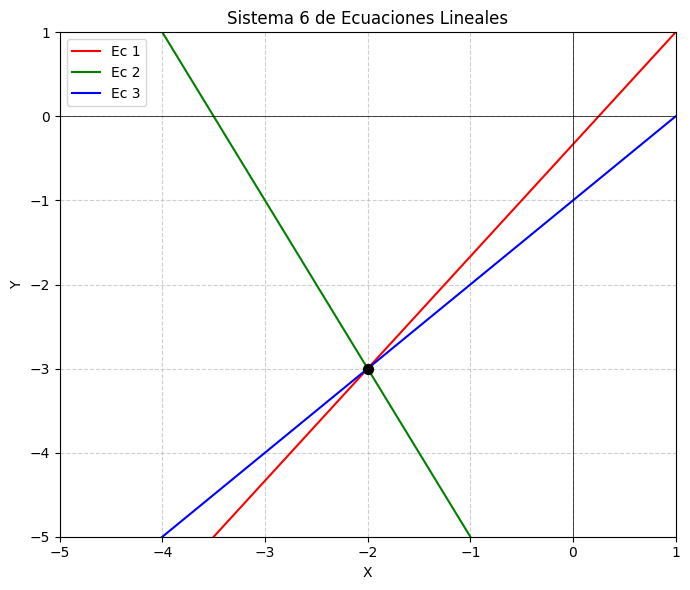

In [90]:
A = np.array([[4, -3], [2, 1], [-1, 1]])
B = np.array([1, -7, -1])

resultado = analizar_sistema(A, B, rango=(-5, 1), n=30, titulo="Sistema 6 de Ecuaciones Lineales")

$$
\begin{cases} 
2x - 3y + 2z = -3 \\ 
-3x + 2y + z = 1 \\ 
4x + y - 3z = 4 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (3 ecuaciones, 3 incógnitas):
-> Rango de A: 3
-> Rango de [A|b]: 3
--------------------------------------------------
✅ EL SISTEMA TIENE SOLUCIÓN EXACTA ÚNICA.
Solución del sistema:
x = 0.67
y = 1.48
z = 0.05


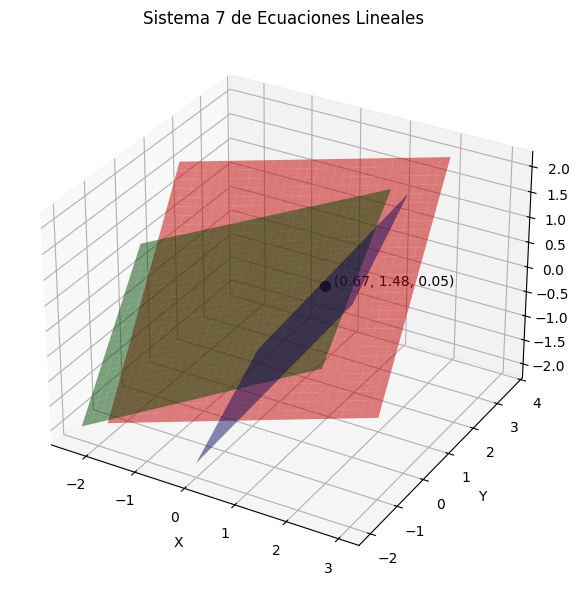

In [91]:
A = np.array([[2, -3, 2], [-3, 2, 1], [4, 1, -3]])
B = np.array([-3, 1, 4])

resultado = analizar_sistema(A, B, rango=(-2, 2), n=30, titulo="Sistema 7 de Ecuaciones Lineales")

$$
\begin{cases} 
4x - 2y + z = 5 \\ 
3x + y - 4z = 0 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (2 ecuaciones, 3 incógnitas):
-> Rango de A: 2
-> Rango de [A|b]: 2
--------------------------------------------------
⚠️ EL SISTEMA TIENE INFINITAS SOLUCIONES EXACTAS.
Solución del sistema:
x = 0.84
y = -0.57
z = 0.49


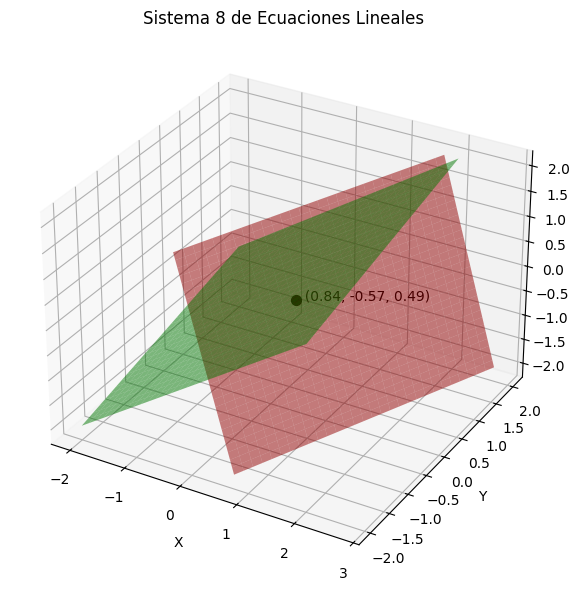

In [92]:
A = np.array([[4, -2, 1], [3, 1, -4]])
B = np.array([5, 0])

resultado = analizar_sistema(A, B, rango=(-2, 2), n=30, titulo="Sistema 8 de Ecuaciones Lineales")

$$
\begin{cases} 
2x + 3y = 5 \\ 
x - 3y = 4 \\ 
x + y = -2 
\end{cases}
$$

--------------------------------------------------
ANÁLISIS DEL SISTEMA (3 ecuaciones, 2 incógnitas):
-> Rango de A: 2
-> Rango de [A|b]: 3
--------------------------------------------------
❌ ALERTA: EL SISTEMA NO TIENE SOLUCIÓN EXACTA.
💡 Acción: Se calcula la mejor aproximación mediante MÍNIMOS CUADRADOS.
Solución del sistema:
x = 2.29
y = -0.43


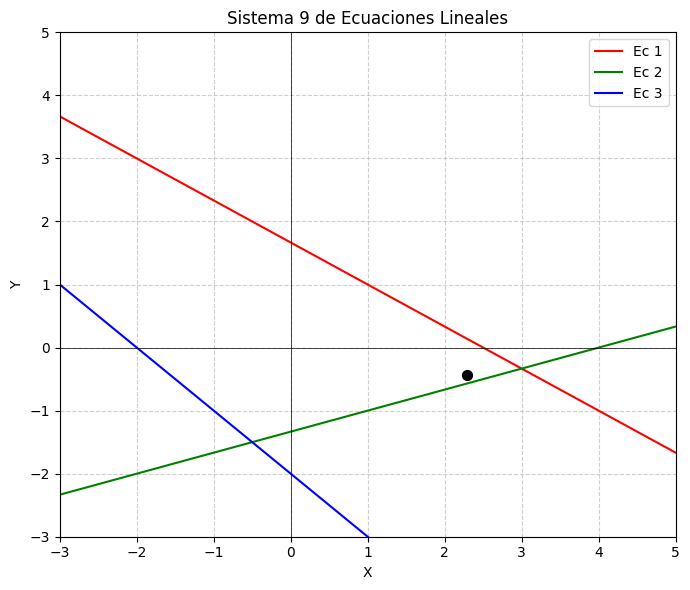

In [95]:
A = np.array([[2, 3], [1, -3], [1, 1]])
B = np.array([5, 4, -2])

resultado = analizar_sistema(A, B, rango=(-3, 5), n=30, titulo="Sistema 9 de Ecuaciones Lineales")

### 2. Aplicación de mínimos cuadrados en inteligencia artificial

En un experimento de optimización de modelos de inteligencia artificial, un equipo de ciencia de datos desea predecir el rendimiento final, medido mediante el porcentaje de precisión de un modelo de clasificación, a partir de cinco características relacionadas con su arquitectura y su entrenamiento. Las variables predictoras son:

* x1: número de capas ocultas de la red neuronal;
* x2: tasa de aprendizaje utilizada;
* x3: porcentaje de regularización L2;
* x4: número de épocas de entrenamiento;
* x5: tamaño del conjunto de datos utilizado.

La variable de respuesta es:

* y: precisión, expresada en porcentaje, obtenida por el modelo.

La matriz de diseño A y el vector de salida b están dados por:

$$
A = \begin{bmatrix}
1 & 1 & 2 & 0 & 3 & 1 \\
1 & 0 & 1 & 1 & 2 & 2 \\
1 & 2 & 1 & 0 & 1 & 1 \\
1 & 3 & 0 & 2 & 0 & 1 \\
1 & 0 & 0 & 3 & 1 & 2 \\
1 & 2 & 2 & 1 & 0 & 0 \\
1 & 1 & 1 & 1 & 1 & 1 \\
1 & 3 & 3 & 0 & 2 & 0 \\
1 & 0 & 2 & 3 & 1 & 1 \\
1 & 1 & 0 & 3 & 2 & 2
\end{bmatrix}, \qquad
b = \begin{bmatrix}
10 \\
8 \\
12 \\
11 \\
9 \\
13 \\
10 \\
15 \\
11 \\
12
\end{bmatrix}.
$$


In [106]:
A = np.array([
    [1, 1, 2, 0, 3, 1],
    [1, 0, 1, 1, 2, 2],
    [1, 2, 1, 0, 1, 1],
    [1, 3, 0, 2, 0, 1],
    [1, 0, 0, 3, 1, 2],
    [1, 2, 2, 1, 0, 0],
    [1, 1, 1, 1, 1, 1],
    [1, 3, 3, 0, 2, 0],
    [1, 0, 2, 3, 1, 1],
    [1, 1, 0, 3, 2, 2]
])

b = np.array([10, 8, 12, 11, 9, 13, 10, 15, 11, 12])

# ==========================================
# Procedimiento matricial: ecuaciones normales
# ==========================================
# A es 10x6 (10 observaciones, 6 parámetros incluyendo el intercepto),
# por lo que el sistema Aβ = b está sobredeterminado y en general no
# tiene solución exacta. β se obtiene minimizando ||Aβ - b||^2, lo que
# equivale a resolver las ecuaciones normales:
#   AᵀA β = Aᵀb   =>   β = (AᵀA)⁻¹ Aᵀb

# Resolver el sistema por mínimos cuadrados
solucion, residuo, rango, s = np.linalg.lstsq(A, b, rcond=None)

# Mostrar resultados
print("Valores singulares:", s)
print("Solución:", solucion)
print("Residuo:", residuo)
print("Rango:", rango)

AtA = A.T @ A
Atb = A.T @ b
beta = np.linalg.solve(AtA, Atb)

print("\nβ (ecuaciones normales):", np.round(beta, 4))
print("β (lstsq, verificación):", np.round(solucion, 4))
print("¿Coinciden?:", np.allclose(beta, solucion))

# Modelo ajustado
nombres = ["β0 (intercepto)", "β1 (x1)", "β2 (x2)", "β3 (x3)", "β4 (x4)", "β5 (x5)"]
print("\nModelo ajustado:")
print("ŷ = {:.2f} + {:.2f}·x1 + {:.2f}·x2 + {:.2f}·x3 + {:.2f}·x4 + ({:.2f})·x5".format(*beta))

# Bondad de ajuste
y_hat = A @ beta
sse = np.sum((b - y_hat) ** 2)
sst = np.sum((b - b.mean()) ** 2)
r2 = 1 - sse / sst

print(f"\nSSE (suma de residuos al cuadrado): {sse:.4f}")
print(f"R² (coeficiente de determinación): {r2:.4f}")


Valores singulares: [9.60264294 5.14373119 3.61948226 2.4724669  1.03651998 0.20774971]
Solución: [ 7.10331126  1.41788079  0.86490066  0.8384106   0.41192053 -0.5397351 ]
Residuo: [7.02516556]
Rango: 6

β (ecuaciones normales): [ 7.1033  1.4179  0.8649  0.8384  0.4119 -0.5397]
β (lstsq, verificación): [ 7.1033  1.4179  0.8649  0.8384  0.4119 -0.5397]
¿Coinciden?: True

Modelo ajustado:
ŷ = 7.10 + 1.42·x1 + 0.86·x2 + 0.84·x3 + 0.41·x4 + (-0.54)·x5

SSE (suma de residuos al cuadrado): 7.0252
R² (coeficiente de determinación): 0.8096


#### Procedimiento matricial

El sistema $A\beta = b$ tiene 10 ecuaciones (observaciones) y solo 6 incógnitas ($\beta_0,\dots,\beta_5$), por lo que está **sobredeterminado** y en general no admite solución exacta. El vector $\beta$ que minimiza el error cuadrático $\|A\beta - b\|^2$ se obtiene resolviendo las **ecuaciones normales**:

$$
A^{\top}A\,\beta = A^{\top}b \qquad\Longrightarrow\qquad \beta = (A^{\top}A)^{-1}A^{\top}b
$$

Este resultado coincide con el obtenido mediante `np.linalg.lstsq` (que internamente usa descomposición SVD por estabilidad numérica), como se verifica en la celda anterior.

#### Modelo ajustado

$$
\hat{y} = 7.10 + 1.42\,x_1 + 0.86\,x_2 + 0.84\,x_3 + 0.41\,x_4 - 0.54\,x_5
$$

con $R^2 \approx 0.81$: el modelo explica cerca del 81 % de la variabilidad observada en la precisión.

#### Interpretación de los coeficientes

* **$\beta_0 = 7.10$**: precisión base estimada cuando todas las variables predictoras valen 0 (valor de referencia del modelo, sin interpretación práctica directa fuera del rango de los datos).
* **$\beta_1 = 1.42$ (capas ocultas)**: por cada capa oculta adicional, la precisión aumenta en promedio 1.42 puntos porcentuales, manteniendo las demás variables constantes. Es el predictor con mayor impacto positivo.
* **$\beta_2 = 0.86$ (tasa de aprendizaje)**: un incremento unitario en esta variable se asocia con un aumento promedio de 0.86 puntos de precisión, controlando por las demás variables.
* **$\beta_3 = 0.84$ (regularización L2)**: un aumento en el porcentaje de regularización se asocia con una mejora promedio de 0.84 puntos de precisión, lo que sugiere que un poco de regularización ayuda a controlar el sobreajuste en este experimento.
* **$\beta_4 = 0.41$ (épocas de entrenamiento)**: cada época adicional aporta en promedio 0.41 puntos de precisión, un efecto positivo pero más moderado que el de las demás variables.
* **$\beta_5 = -0.54$ (tamaño del conjunto de datos)**: es el único coeficiente negativo; al aumentar el tamaño del dataset (manteniendo fijas las demás variables), la precisión disminuye en promedio 0.54 puntos. Esto no implica que más datos perjudiquen al modelo en general, sino que, dentro de esta muestra, esa variable está correlacionada con configuraciones (arquitectura/entrenamiento) menos favorables para la precisión final.

En conjunto, el modelo indica que el rendimiento del clasificador está más influenciado por la profundidad de la red (capas ocultas) y por la tasa de aprendizaje/regularización, mientras que el tamaño del dataset por sí solo no garantiza mejor precisión si no se ajustan adecuadamente los demás hiperparámetros.


### 3. Determinante y valores propios 

¿Cómo se relaciona el determinante de una matriz cuadrada con sus valores propios? Explique el fundamento teórico y resuelva un ejemplo numérico que permita verificar dicha relación.


#### Fundamento teórico

Sea $A$ una matriz cuadrada $n \times n$. Sus valores propios $\lambda_1, \lambda_2, \dots, \lambda_n$ (contados con multiplicidad, posiblemente complejos) son las raíces del **polinomio característico**:

$$
p(\lambda) = \det(A - \lambda I) = 0
$$

Por el teorema fundamental del álgebra, este polinomio se factoriza completamente sobre los complejos:

$$
\det(\lambda I - A) = (\lambda - \lambda_1)(\lambda - \lambda_2)\cdots(\lambda - \lambda_n)
$$

Evaluando en $\lambda = 0$:

$$
\det(-A) = (-\lambda_1)(-\lambda_2)\cdots(-\lambda_n) \quad\Longrightarrow\quad (-1)^n\det(A) = (-1)^n \prod_{i=1}^{n}\lambda_i
$$

de donde se obtiene la relación fundamental:

$$
\boxed{\det(A) = \prod_{i=1}^{n}\lambda_i = \lambda_1 \cdot \lambda_2 \cdots \lambda_n}
$$

**Interpretación equivalente (triangularización):** toda matriz cuadrada admite una descomposición de Schur $A = QUQ^{-1}$, donde $U$ es triangular superior con los valores propios de $A$ en su diagonal y $Q$ es unitaria (por lo que $\det(Q)\det(Q^{-1}) = 1$). Como el determinante de una matriz triangular es el producto de su diagonal:

$$
\det(A) = \det(Q)\det(U)\det(Q^{-1}) = \det(U) = \lambda_1\lambda_2\cdots\lambda_n
$$

**Consecuencia clave:** $A$ es singular ($\det(A) = 0$) si y solo si al menos uno de sus valores propios es cero. Esto conecta directamente este resultado con la Sección 1: un sistema homogéneo $Ax=0$ tiene soluciones no triviales exactamente cuando $A$ tiene a $\lambda=0$ como valor propio.

#### Ejemplo numérico


In [108]:
A_ejemplo = np.array([
    [4, 2, 0],
    [1, 3, 1],
    [5, 1, 2]
])

valores_propios, _ = np.linalg.eig(A_ejemplo)
det_directo = np.linalg.det(A_ejemplo)
producto_valores_propios = np.prod(valores_propios)

print("Matriz A:")
print(A_ejemplo)
print()
print("Valores propios (λ):", np.round(valores_propios, 4))
print(f"Determinante de A (np.linalg.det):     {det_directo:.4f}")
print(f"Producto de los valores propios (Πλᵢ): {producto_valores_propios.real:.4f}")
print("¿Coinciden?:", np.isclose(det_directo, producto_valores_propios.real))


Matriz A:
[[4 2 0]
 [1 3 1]
 [5 1 2]]

Valores propios (λ): [5.8126+0.j     1.5937+1.3904j 1.5937-1.3904j]
Determinante de A (np.linalg.det):     26.0000
Producto de los valores propios (Πλᵢ): 26.0000
¿Coinciden?: True


### 4. Traza y valores propios

¿Qué vínculo existe entre la traza de una matriz cuadrada y la suma de sus valores propios? Justifique la respuesta teóricamente y compruébela mediante un ejemplo numérico.

#### Fundamento teórico

Sea $A$ una matriz cuadrada $n \times n$ con valores propios $\lambda_1, \lambda_2, \dots, \lambda_n$ (contados con multiplicidad, posiblemente complejos). El polinomio característico es:

$$
p(\lambda) = \det(\lambda I - A) = \lambda^n - \operatorname{tr}(A)\,\lambda^{n-1} + \cdots + (-1)^n \det(A)
$$

Por otro lado, al factorizar sobre sus raíces (los valores propios):

$$
p(\lambda) = (\lambda - \lambda_1)(\lambda - \lambda_2)\cdots(\lambda - \lambda_n) = \lambda^n - \Big(\sum_{i=1}^{n}\lambda_i\Big)\lambda^{n-1} + \cdots + (-1)^n\prod_{i=1}^{n}\lambda_i
$$

Comparando los coeficientes de $\lambda^{n-1}$ en ambas expresiones se obtiene la relación fundamental:

$$
\boxed{\operatorname{tr}(A) = \sum_{i=1}^{n}\lambda_i = \lambda_1 + \lambda_2 + \cdots + \lambda_n}
$$

**Interpretación equivalente (triangularización):** al igual que en la Sección 3, toda matriz cuadrada admite una descomposición de Schur $A = QUQ^{-1}$ con $U$ triangular superior y los valores propios de $A$ en su diagonal. La traza es invariante bajo transformaciones de semejanza, es decir $\operatorname{tr}(PMP^{-1}) = \operatorname{tr}(M)$ para cualquier $P$ invertible, ya que $\operatorname{tr}(PMP^{-1}) = \operatorname{tr}(P^{-1}PM) = \operatorname{tr}(M)$ (propiedad cíclica de la traza). Por lo tanto:

$$
\operatorname{tr}(A) = \operatorname{tr}(QUQ^{-1}) = \operatorname{tr}(U) = \lambda_1 + \lambda_2 + \cdots + \lambda_n
$$

ya que la traza de una matriz triangular es la suma de su diagonal.

**Nota:** aunque los valores propios de una matriz real pueden ser complejos, siempre aparecen en pares conjugados ($a+bi$ y $a-bi$), por lo que su suma (y su producto) es siempre un número real, consistente con que $\operatorname{tr}(A)$ y $\det(A)$ son reales cuando $A$ lo es.

#### Ejemplo numérico

Se reutiliza la misma matriz $A$ de la Sección 3.


In [109]:
A_ejemplo = np.array([
    [5, 2, 4],
    [9, 4, 1],
    [8, 3, 2]
])

valores_propios_2, _ = np.linalg.eig(A_ejemplo)
traza_directa = np.trace(A_ejemplo)
suma_valores_propios = np.sum(valores_propios_2)

print("Matriz A:")
print(A_ejemplo)
print()
print("Valores propios (λ):", np.round(valores_propios_2, 4))
print(f"Traza de A (np.trace):                {traza_directa:.4f}")
print(f"Suma de los valores propios (Σλᵢ):     {suma_valores_propios.real:.4f}")
print("¿Coinciden?:", np.isclose(traza_directa, suma_valores_propios.real))


Matriz A:
[[5 2 4]
 [9 4 1]
 [8 3 2]]

Valores propios (λ): [12.1343 -1.8153  0.681 ]
Traza de A (np.trace):                11.0000
Suma de los valores propios (Σλᵢ):     11.0000
¿Coinciden?: True


### 5. Operaciones matriciales

Considere las matrices

$$
A = \begin{bmatrix}
0.70 & 0.15 & 0.15 \\
0.20 & 0.80 & 0.15 \\
0.10 & 0.05 & 0.70
\end{bmatrix}, \qquad
B = \begin{bmatrix}
0.10 & 0.45 & 0.00 \\
0.15 & 0.00 & 0.37 \\
0.23 & 0.05 & 0.72
\end{bmatrix}.
$$

Realice las siguientes operaciones:

a) Calcule A−1

In [111]:
A = np.array([
    [0.70, 0.15, 0.15],
    [0.20, 0.80, 0.15],
    [0.10, 0.05, 0.70]
])

B = np.array([
    [0.10, 0.45, 0.00],
    [0.15, 0.00, 0.37],
    [0.23, 0.05, 0.72]
])

A_inv = np.linalg.inv(A)

print("Matriz A :")
print(A)
print()
print("Matriz A^(-1) :")
print(A_inv)

Matriz A :
[[0.7  0.15 0.15]
 [0.2  0.8  0.15]
 [0.1  0.05 0.7 ]]

Matriz A^(-1) :
[[ 1.54545455 -0.27272727 -0.27272727]
 [-0.34965035  1.32867133 -0.20979021]
 [-0.1958042  -0.05594406  1.48251748]]


b) Calcule B−1

In [112]:
B_inv = np.linalg.inv(B)

print("\nMatriz B :")
print(B)
print()
print("Matriz B^(-1) :")
print(B_inv)


Matriz B :
[[0.1  0.45 0.  ]
 [0.15 0.   0.37]
 [0.23 0.05 0.72]]

Matriz B^(-1) :
[[  1.5220074   26.65569724 -13.69806664]
 [  1.88399835  -5.92348828   3.04401481]
 [ -0.61703003  -8.10366104   5.55327026]]


c) Determine det(A) y det(B)

In [113]:
det_A = np.linalg.det(A)
det_B = np.linalg.det(B)

print("\nDeterminante de A:", det_A)
print("Determinante de B:", det_B)


Determinante de A: 0.3575
Determinante de B: -0.012154999999999984


d) Calcule los valores propios y los vectores propios de A y de B.

In [114]:
valores_propios_A, vectores_propios_A = np.linalg.eig(A)
valores_propios_B, vectores_propios_B = np.linalg.eig(B)

print("\nValores propios de A:", valores_propios_A)
print("Vectores propios de A:\n", vectores_propios_A)
print("\nValores propios de B:", valores_propios_B)
print("Vectores propios de B:\n", vectores_propios_B)


Valores propios de A: [1.   0.55 0.65]
Vectores propios de A:
 [[-5.44949261e-01 -8.16496581e-01  4.97760620e-16]
 [-7.78498944e-01  4.08248290e-01 -7.07106781e-01]
 [-3.11399578e-01  4.08248290e-01  7.07106781e-01]]

Valores propios de B: [ 0.81897216  0.12234183 -0.12131398]
Vectores propios de B:
 [[-0.27362768 -0.93097708  0.87655692]
 [-0.4371793  -0.04622162 -0.43109845]
 [-0.85673925  0.3621398  -0.21401423]]


e) Calcule $$A^T \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & -1 \end{bmatrix}.$$

In [115]:
#A^T * Matriz
resultado = A.T @ np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, -1]
])

print("\nResultado de A^T * Matriz:")
print(resultado)


Resultado de A^T * Matriz:
[[ 0.7   0.2  -0.1 ]
 [ 0.15  0.8  -0.05]
 [ 0.15  0.15 -0.7 ]]


f) Calcule $$A^T \begin{bmatrix} 1 & 0 & 0 \\ 0 & -1 & 0 \\ 0 & 0 & 1 \end{bmatrix}.$$

In [116]:
resultado = A.T @ np.array([
    [1, 0, 0],
    [0, -1, 0],
    [0, 0, 1]
])

print("\nResultado de A^T * Matriz:")
print(resultado)


Resultado de A^T * Matriz:
[[ 0.7  -0.2   0.1 ]
 [ 0.15 -0.8   0.05]
 [ 0.15 -0.15  0.7 ]]


g) Calcule $$B^T \begin{bmatrix} -1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & -1 \end{bmatrix}.$$

In [118]:
resultado = B.T @ np.array([
    [-1, 0, 0],
    [0, 1, 0],
    [0, 0, -1]
])

print("\nResultado de B^T * Matriz:")
print(resultado)


Resultado de B^T * Matriz:
[[-0.1   0.15 -0.23]
 [-0.45  0.   -0.05]
 [ 0.    0.37 -0.72]]


h) Calcule $$3A^3 - 2B^2 + 5I.$$

In [120]:
# Matriz identidad de 3x3
I = np.eye(3)

resultado = 3 * np.linalg.matrix_power(A, 3) - 2 * np.linalg.matrix_power(B, 2) + 5 * I

print("\nResultado de 3*A^3 - 2*B^2 + 5*I:")
print(resultado)


Resultado de 3*A^3 - 2*B^2 + 5*I:
[[6.17775  0.743625 0.500625]
 [0.9443   6.634    0.449325]
 [0.13055  0.081375 5.11045 ]]


i) Calcule $$3A^{-1} + 2B + 2I.$$

In [121]:
resultado = 3 * np.linalg.inv(A) + 2 * B + 2 * I

print("\nResultado de 3*A^-1 + 2*B + 2*I:")
print(resultado)


Resultado de 3*A^-1 + 2*B + 2*I:
[[ 6.83636364  0.08181818 -0.81818182]
 [-0.74895105  5.98601399  0.11062937]
 [-0.12741259 -0.06783217  7.88755245]]
